# Spotify Track Popularity Analysis
**Author:** Nattakan | **Date:** May 2026 | **Tools:** Python, Pandas, Seaborn, Scikit-learn

## Project Overview

This project explores what makes a Spotify track popular using 114,000+ real 
tracks sourced from the Spotify API, spanning multiple genres from acoustic 
to hip-hop, EDM, and classical.

**Business Question:**
*Which audio features and track characteristics best predict a song's 
popularity on Spotify?*

**Goals:**
- Understand the distribution and patterns of track popularity across genres
- Identify which audio features (danceability, energy, valence, acousticness, 
  speechiness) correlate with popularity
- Build a machine learning model to predict popularity score
- Deploy findings as an interactive Streamlit dashboard


## Set up Jupyter notebook

In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

#modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

## Load dataset
The dataset contains 114,000 tracks with 21 features sourced from the 
Spotify API, including rich audio attributes and the target variable: 
`popularity` (score 0–100).

In [101]:
df = pd.read_csv("spotify_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Exploratory Data Analysis

### Data overview
Before analysis, we inspect the dataset structure, data types, and missing values to understand data quality and identify any cleaning needed.

In [104]:
print(f'Total records: {df.shape[0]}')
print(f'Total features: {df.shape[1]}')

df.info()

Total records: 114000
Total features: 21
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  flo

#### Missing values

In [106]:
df.isnull().sum()

index               0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [107]:
df = df.dropna()
print(f"Rows after dropping nulls: {len(df)}") 

Rows after dropping nulls: 113999


**Findings:**
- 114,000 tracks with 21 columns
- Missing values are negligible => `artists`, `album_name`, and `track_name` 
  each missing only 1 row (0.001% of data)
- 9 audio features correctly stored as float64 
- `explicit` stored as bool => will be converted to int (0/1) for modelling
- `mode`, `key`, and `time_signature` stored as int64 but should be treated 
  as categorical in analysis
- No `release_date` column => year-based trend analysis not available in this dataset

#### Statistical summary

In [110]:
numerical_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
df[numerical_features].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,0.566801,0.641383,-8.258950,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695
std,0.173543,0.251530,5.029357,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500
50%,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,0.695000,0.854000,-5.003000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


In [111]:
print("Popularity = 0:", (df['popularity'] == 0).sum())
print("Tempo = 0:", (df['tempo'] == 0).sum())

Popularity = 0: 16019
Tempo = 0: 157


In [112]:
df = df[df['tempo'] > 0]
print(f"Rows after removing 0 tempo: {len(df)}")

Rows after removing 0 tempo: 113842


**Data Cleaning Decisions:**
- Retained all 114,000 tracks including those with popularity = 0 => 
  Spotify's popularity score is a 0–100 scale reflecting relative 
  streaming activity, so 0 indicates an extremely rarely streamed track 
  not missing data. Removing these would bias the model toward 
  mid-to-high popularity predictions
- Removed 157 tracks with tempo = 0 (0.1%) => no valid song has 0 BPM, 
  indicating missing data from Spotify's audio analysis API
- **Final dataset: 113,843 tracks** ready for analysis and modelling

### Target Variable

#### Distribution for numeric variables

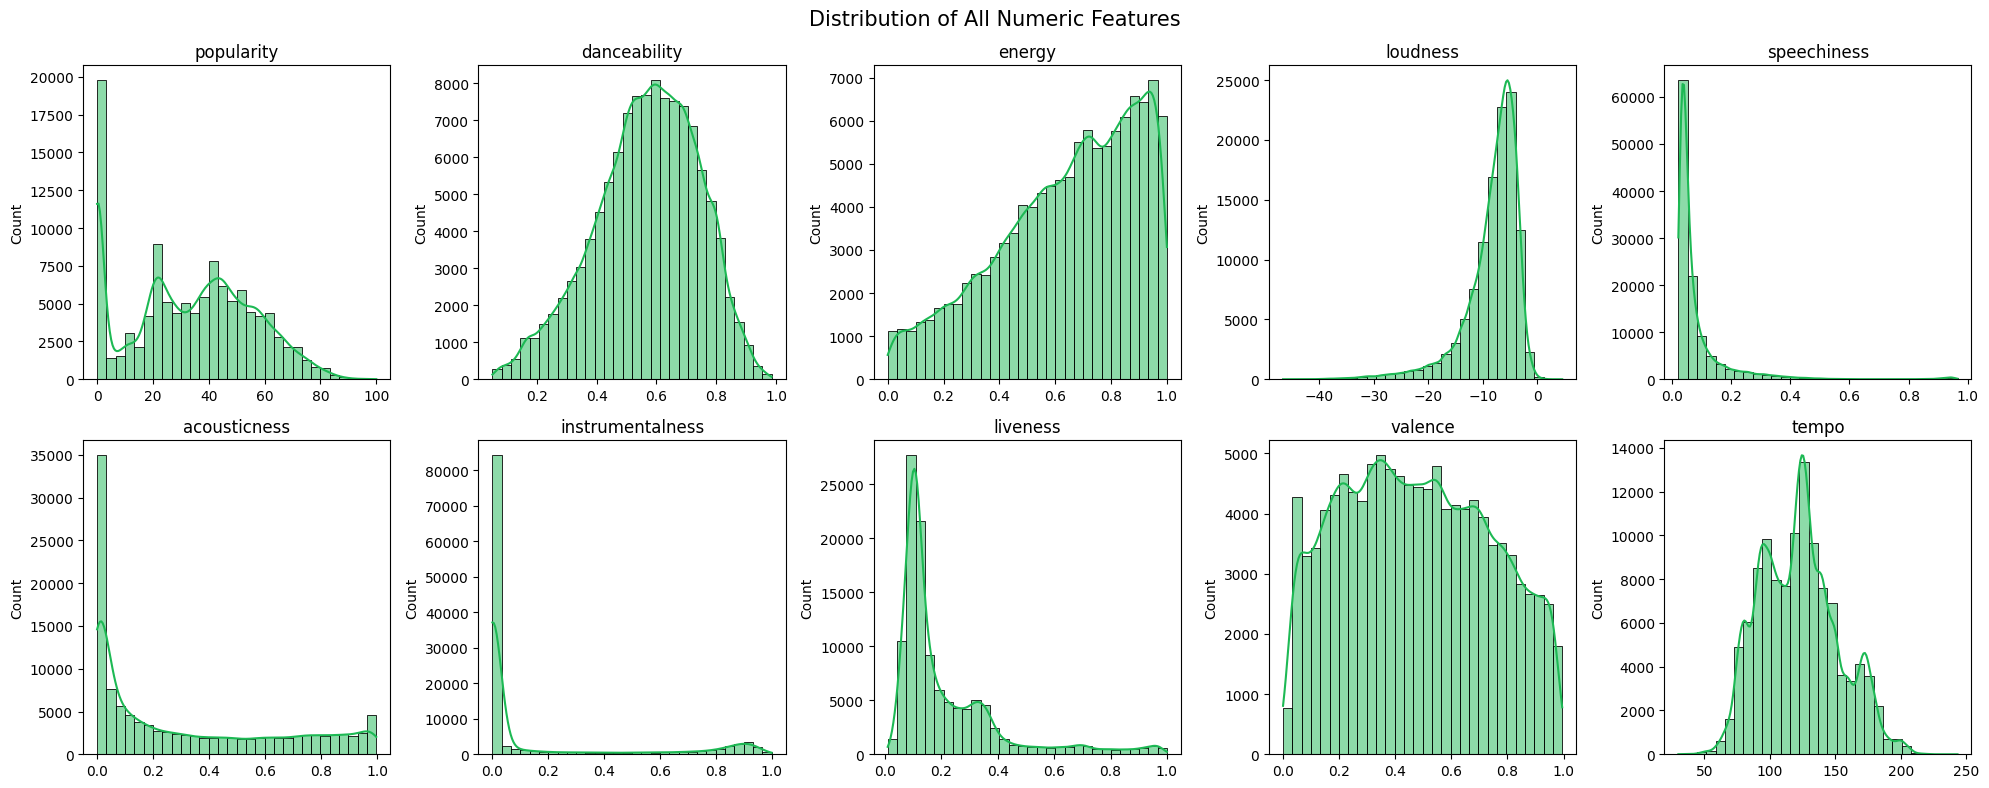

In [116]:
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], ax=ax, color='#1DB954', kde=True, bins=30)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Distribution of All Numeric Features', fontsize=15)
plt.tight_layout()
plt.savefig('all_distributions.png', dpi=150)
plt.show()

**Findings:**
- `danceability`, `tempo` and `valence` are roughly normally distributed
- `speechiness`, `acousticness`, `instrumentalness`, and `liveness` 
  are heavily right-skewed => most tracks score low, with few exceptions
- `energy` skews high => most tracks are energetic
- `loudness` is left-skewed with a long tail toward very quiet tracks
- Features with heavy skew may need log transformation before modelling

In [118]:
skew = df['popularity'].skew()
print(f"Skewness: {skew:.3f}")
print(f"Mean: {df['popularity'].mean():.1f}")
print(f"Median: {df['popularity'].median():.1f}")
print(f"Std: {df['popularity'].std():.1f}")

Skewness: 0.047
Mean: 33.2
Median: 34.0
Std: 22.3


**Findings:**
- Popularity is approximately normally distributed with very low skewness (0.047)
- Mean popularity is 33.2 with a median of 34.0 => the small gap between 
  these confirms the distribution is symmetric with no strong skew
- Standard deviation of 22.3 indicates wide variation across tracks, 
  meaning the dataset captures both niche and mainstream songs well
- The centre of mass around 33 suggests most tracks sit at low-to-mid 
  popularity => very high popularity (80+) is relatively rare on Spotify


**Modelling implication:** The near-normal distribution of popularity means 
no target transformation is needed before training a regression model.

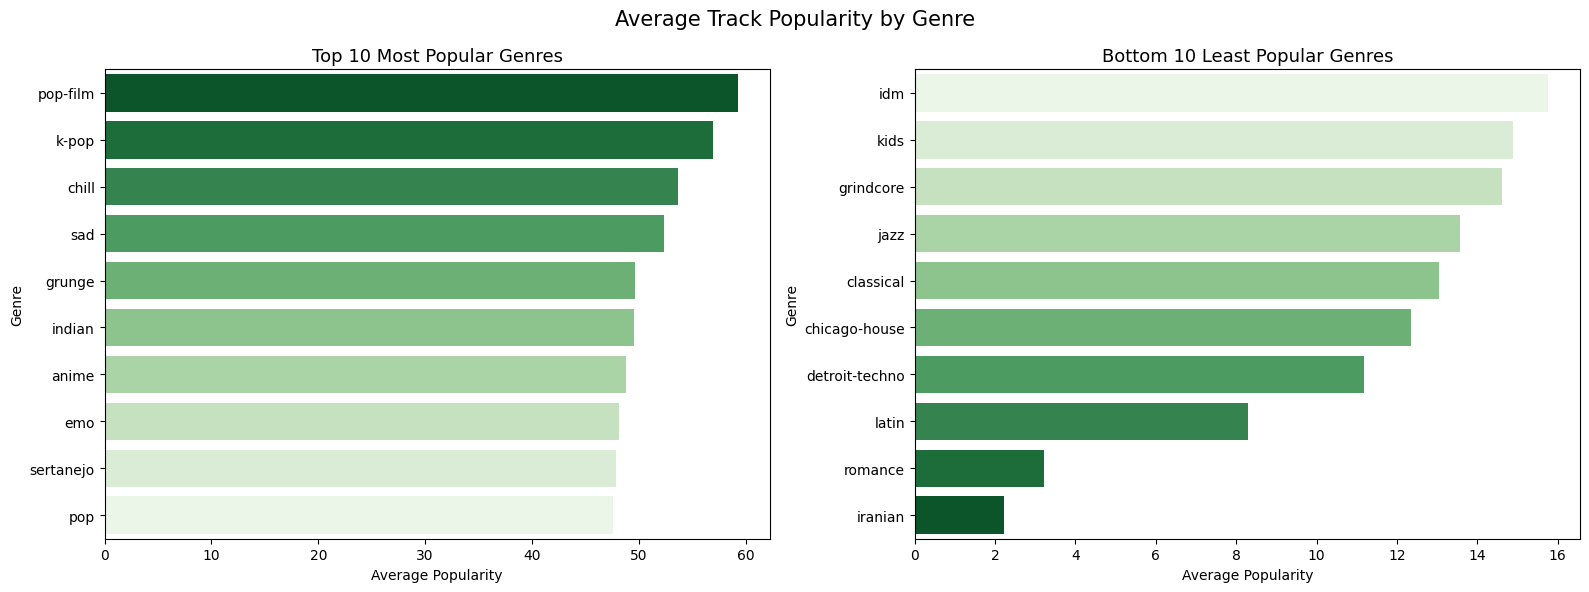

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

sns.barplot(ax=axes[0], x=genre_pop.head(10).values, y=genre_pop.head(10).index, 
            hue=genre_pop.head(10).index, legend=False, palette='Greens_r')
axes[0].set_title('Top 10 Most Popular Genres', fontsize=13)
axes[0].set_xlabel('Average Popularity')
axes[0].set_ylabel('Genre')

sns.barplot(ax=axes[1], x=genre_pop.tail(10).values, y=genre_pop.tail(10).index, 
            hue=genre_pop.tail(10).index, legend=False, palette='Greens')
axes[1].set_title('Bottom 10 Least Popular Genres', fontsize=13)
axes[1].set_xlabel('Average Popularity')
axes[1].set_ylabel('Genre')

plt.suptitle('Average Track Popularity by Genre', fontsize=15)
plt.tight_layout()
plt.savefig('popularity_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

**Findings:**
- **pop-film** ranks highest with 60 average popularity, followed by 
  **k-pop** (57) and **chill** (54) => suggesting soundtrack and 
  mood-based genres perform strongly on Spotify
- **sad** and **grunge** appearing in the top 10 is interesting => 
  emotional genres appear to have a dedicated and engaged listener base
- The bottom 10 are dominated by niche or regional genres — **iranian** 
  (2) and **romance** (3) score extremely low, likely due to limited 
  global streaming reach rather than audio quality
- **idm**, **grindcore**, and **detroit-techno** sitting at the bottom 
  reflects their niche appeal outside mainstream streaming audiences
- The gap between top (60) and bottom (2) is dramatic, suggesting 
  genre is likely to be an important feature in our prediction model

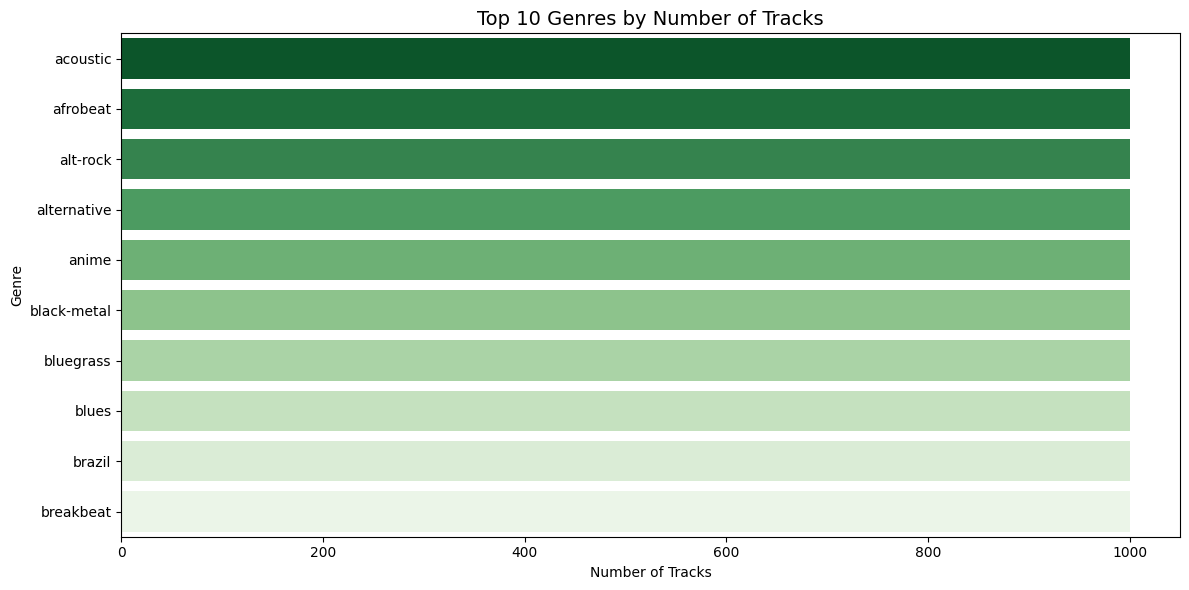

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
breakbeat      1000
Name: count, dtype: int64


In [123]:
genre_counts = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index,
            hue=genre_counts.index, legend=False, palette='Greens_r')
plt.title('Top 10 Genres by Number of Tracks', fontsize=14)
plt.xlabel('Number of Tracks')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_track_count.png', dpi=150)
plt.show()

print(genre_counts)

**Findings:**
- The dataset is remarkably balanced across genres => every genre contains 
  approximately 1,000 tracks (997–1,000)
- This is almost certainly intentional => the dataset was constructed by 
  sampling 1,000 tracks per genre from the Spotify API
- This balance is actually ideal for machine learning => the model won't 
  be biased toward predicting dominant genres simply because they have 
  more training examples
- However, it means genre distribution does not reflect real-world 
  Spotify proportions => pop and hip-hop would dominate in reality

In [125]:
df_unique = df.drop_duplicates(subset='track_id', keep='first')
print(f"Unique tracks: {len(df_unique)}")

Unique tracks: 89583


**Note:** The dataset assigns tracks to multiple genres, meaning the same 
track can appear more than once. For genre analysis we use the full dataset. 
For artist and song rankings we deduplicate by track_id to avoid double counting.

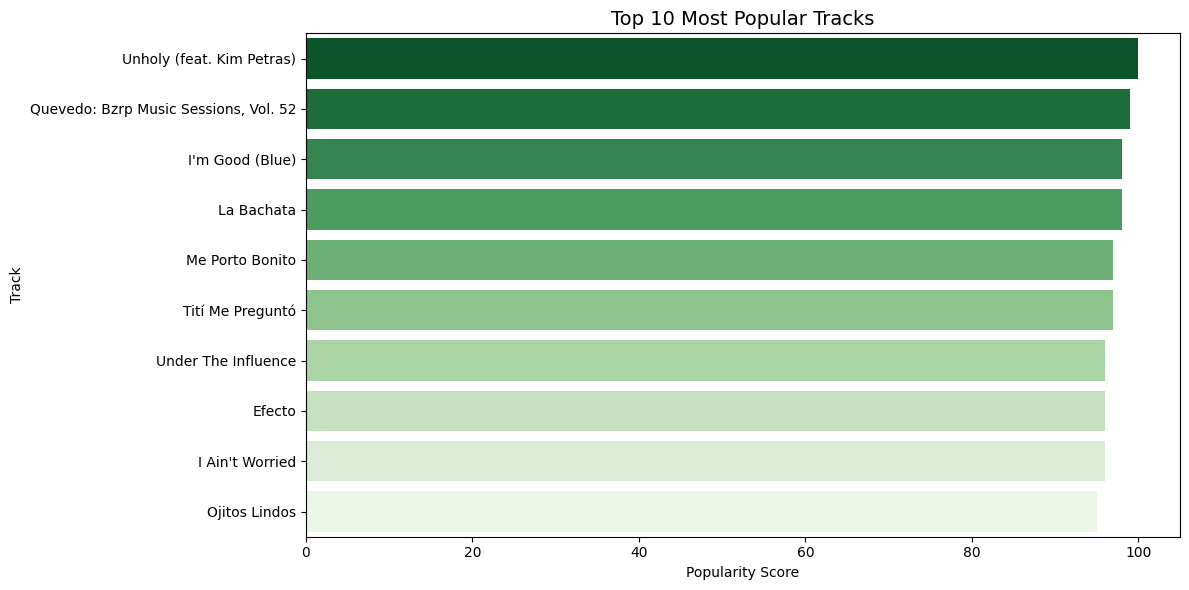

In [127]:
# Top 10 most popular songs
top_songs = df_unique.nlargest(10, 'popularity')[['track_name', 'artists', 'track_genre', 'popularity']]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_songs['popularity'], y=top_songs['track_name'],
            hue=top_songs['track_name'], legend=False, palette='Greens_r')
plt.title('Top 10 Most Popular Tracks', fontsize=14)
plt.xlabel('Popularity Score')
plt.ylabel('Track')
plt.tight_layout()
plt.savefig('top_songs.png', dpi=150)
plt.show()

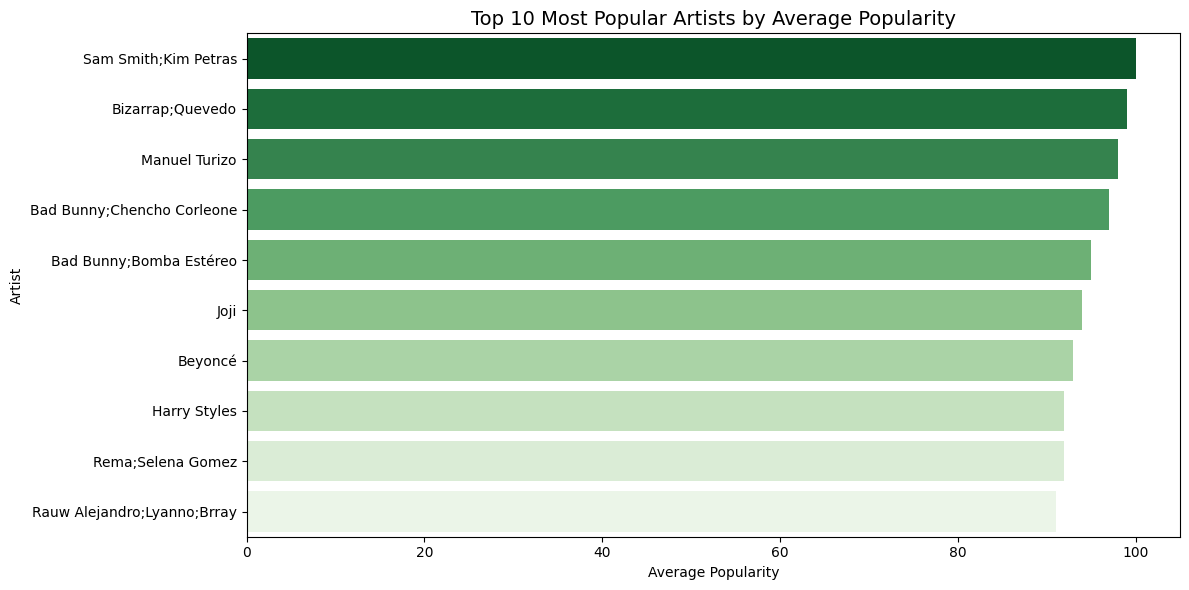

In [128]:
top_artists = df_unique.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.values, y=top_artists.index,
            hue=top_artists.index, legend=False, palette='Greens_r')
plt.title('Top 10 Most Popular Artists by Average Popularity', fontsize=14)
plt.xlabel('Average Popularity')
plt.ylabel('Artist')
plt.tight_layout()
plt.savefig('top_artists.png', dpi=150)
plt.show()

### Feature Distributions & Outliers

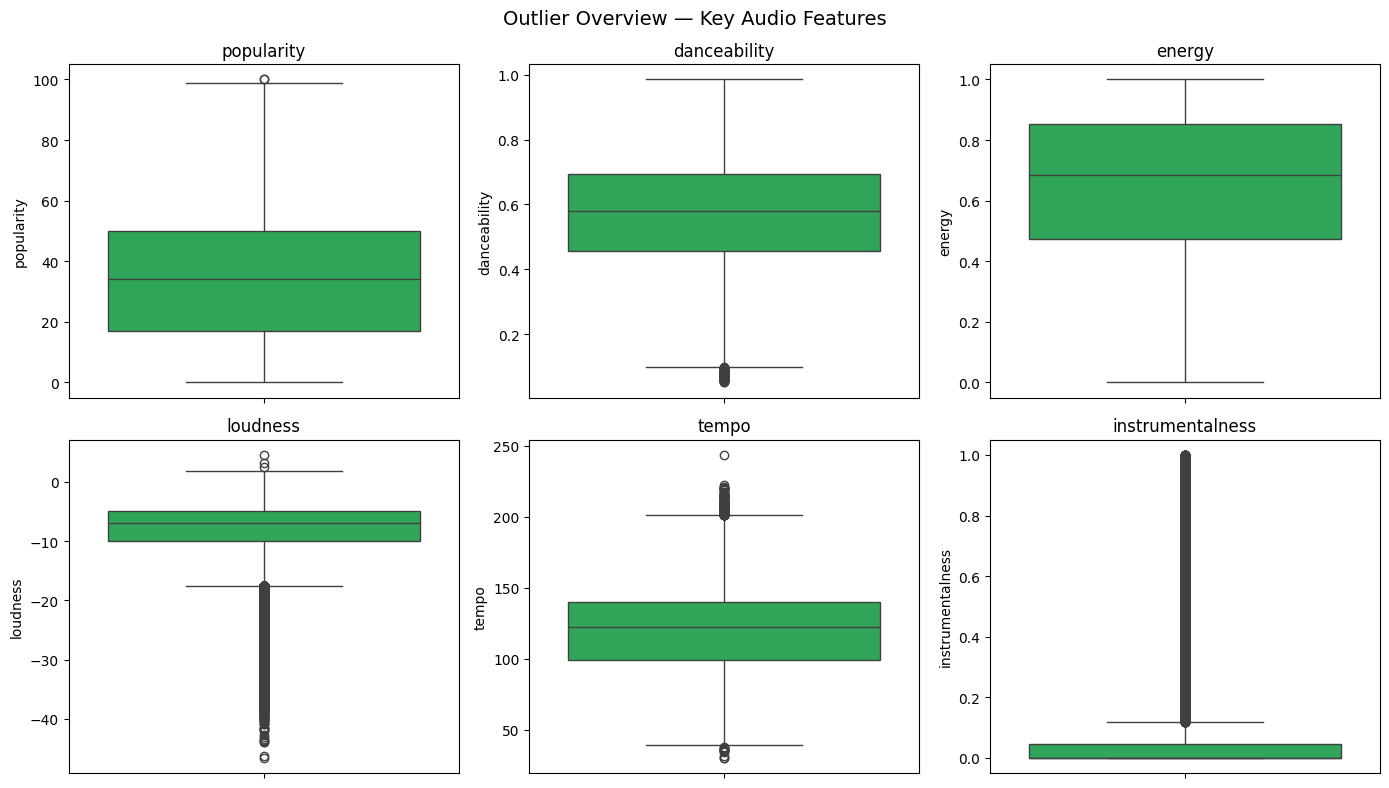

In [130]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['popularity', 'danceability', 'energy', 'loudness', 'tempo', 'instrumentalness']

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(y=df[col], ax=ax, color='#1DB954')
    ax.set_title(col)

plt.suptitle('Outlier Overview — Key Audio Features', fontsize=14)
plt.tight_layout()
plt.savefig('outliers.png', dpi=150)
plt.show()

**Findings:**

- **popularity** — wide spread (0–100) with a few tracks scoring 100, 
  confirming our earlier finding of a near-normal distribution centred ~33

- **danceability** — mostly between 0.45–0.70, a few extreme outliers 
  near 0. Most tracks have moderate-to-high danceability

- **energy** — skewed high, median around 0.65, meaning most tracks 
  in this dataset lean energetic. Very few low-energy tracks

- **loudness** — majority of tracks sit between -10 and -5 dB with 
  significant outliers dropping to -50 dB. Extremely quiet tracks 
  are rare but present

- **tempo** — centred around 120 BPM (typical pop/dance range) with 
  some outliers above 200 BPM and a few near 0, which may indicate 
  data errors worth investigating

- **instrumentalness** — heavily skewed toward 0, meaning most tracks 
  have vocals. A small number reach close to 1.0 (fully instrumental), 
  which aligns with genres like classical and IDM in the dataset

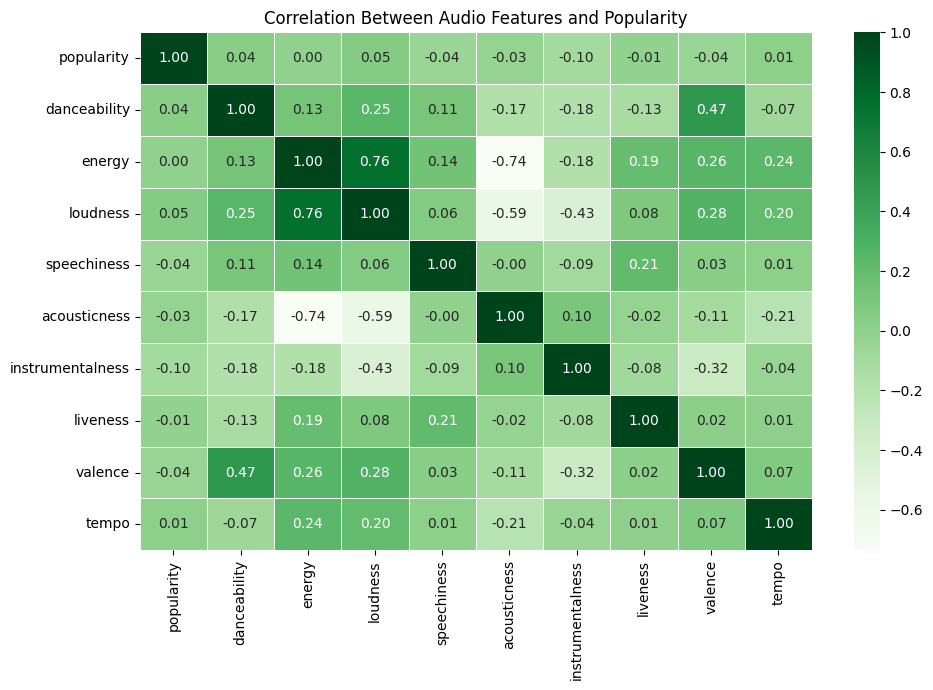

In [132]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', 
            cmap='Greens', linewidths=0.5)
plt.title('Correlation Between Audio Features and Popularity')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

**Findings — Correlation Heatmap:**

**Popularity correlations:**
- No audio feature strongly predicts popularity => the strongest relationships 
  are loudness (0.05) and instrumentalness (-0.10), both very weak
- Tracks with more instrumental content tend to be slightly less popular (-0.10), 
  suggesting vocal-driven songs perform better on Spotify
- This confirms that popularity is likely driven by external factors such as 
  artist reputation, playlist placement, and marketing rather than sound alone

**Strong relationships between features:**
- energy vs loudness (0.76) => louder production and high energy almost always 
  go together, reflecting modern mixing and mastering trends
- energy vs acousticness (-0.74) => acoustic songs are significantly less 
  energetic, confirming these represent opposite ends of the production spectrum
- loudness vs acousticness (-0.59) => acoustic tracks are noticeably quieter
- danceability vs valence (0.47) => happier sounding songs tend to be 
  more danceable
- instrumentalness vs valence (-0.32) => instrumental tracks tend to 
  score lower on emotional positivity

**Modelling implication:**
- Audio features alone are weak predictors of popularity
- The high correlation between energy, loudness, and acousticness suggests 
  potential multicollinearity => we may need to drop one of these features 
  before training to avoid redundant information in the model
- Genre, artist, and explicit content will likely contribute more 
  predictive power than audio features

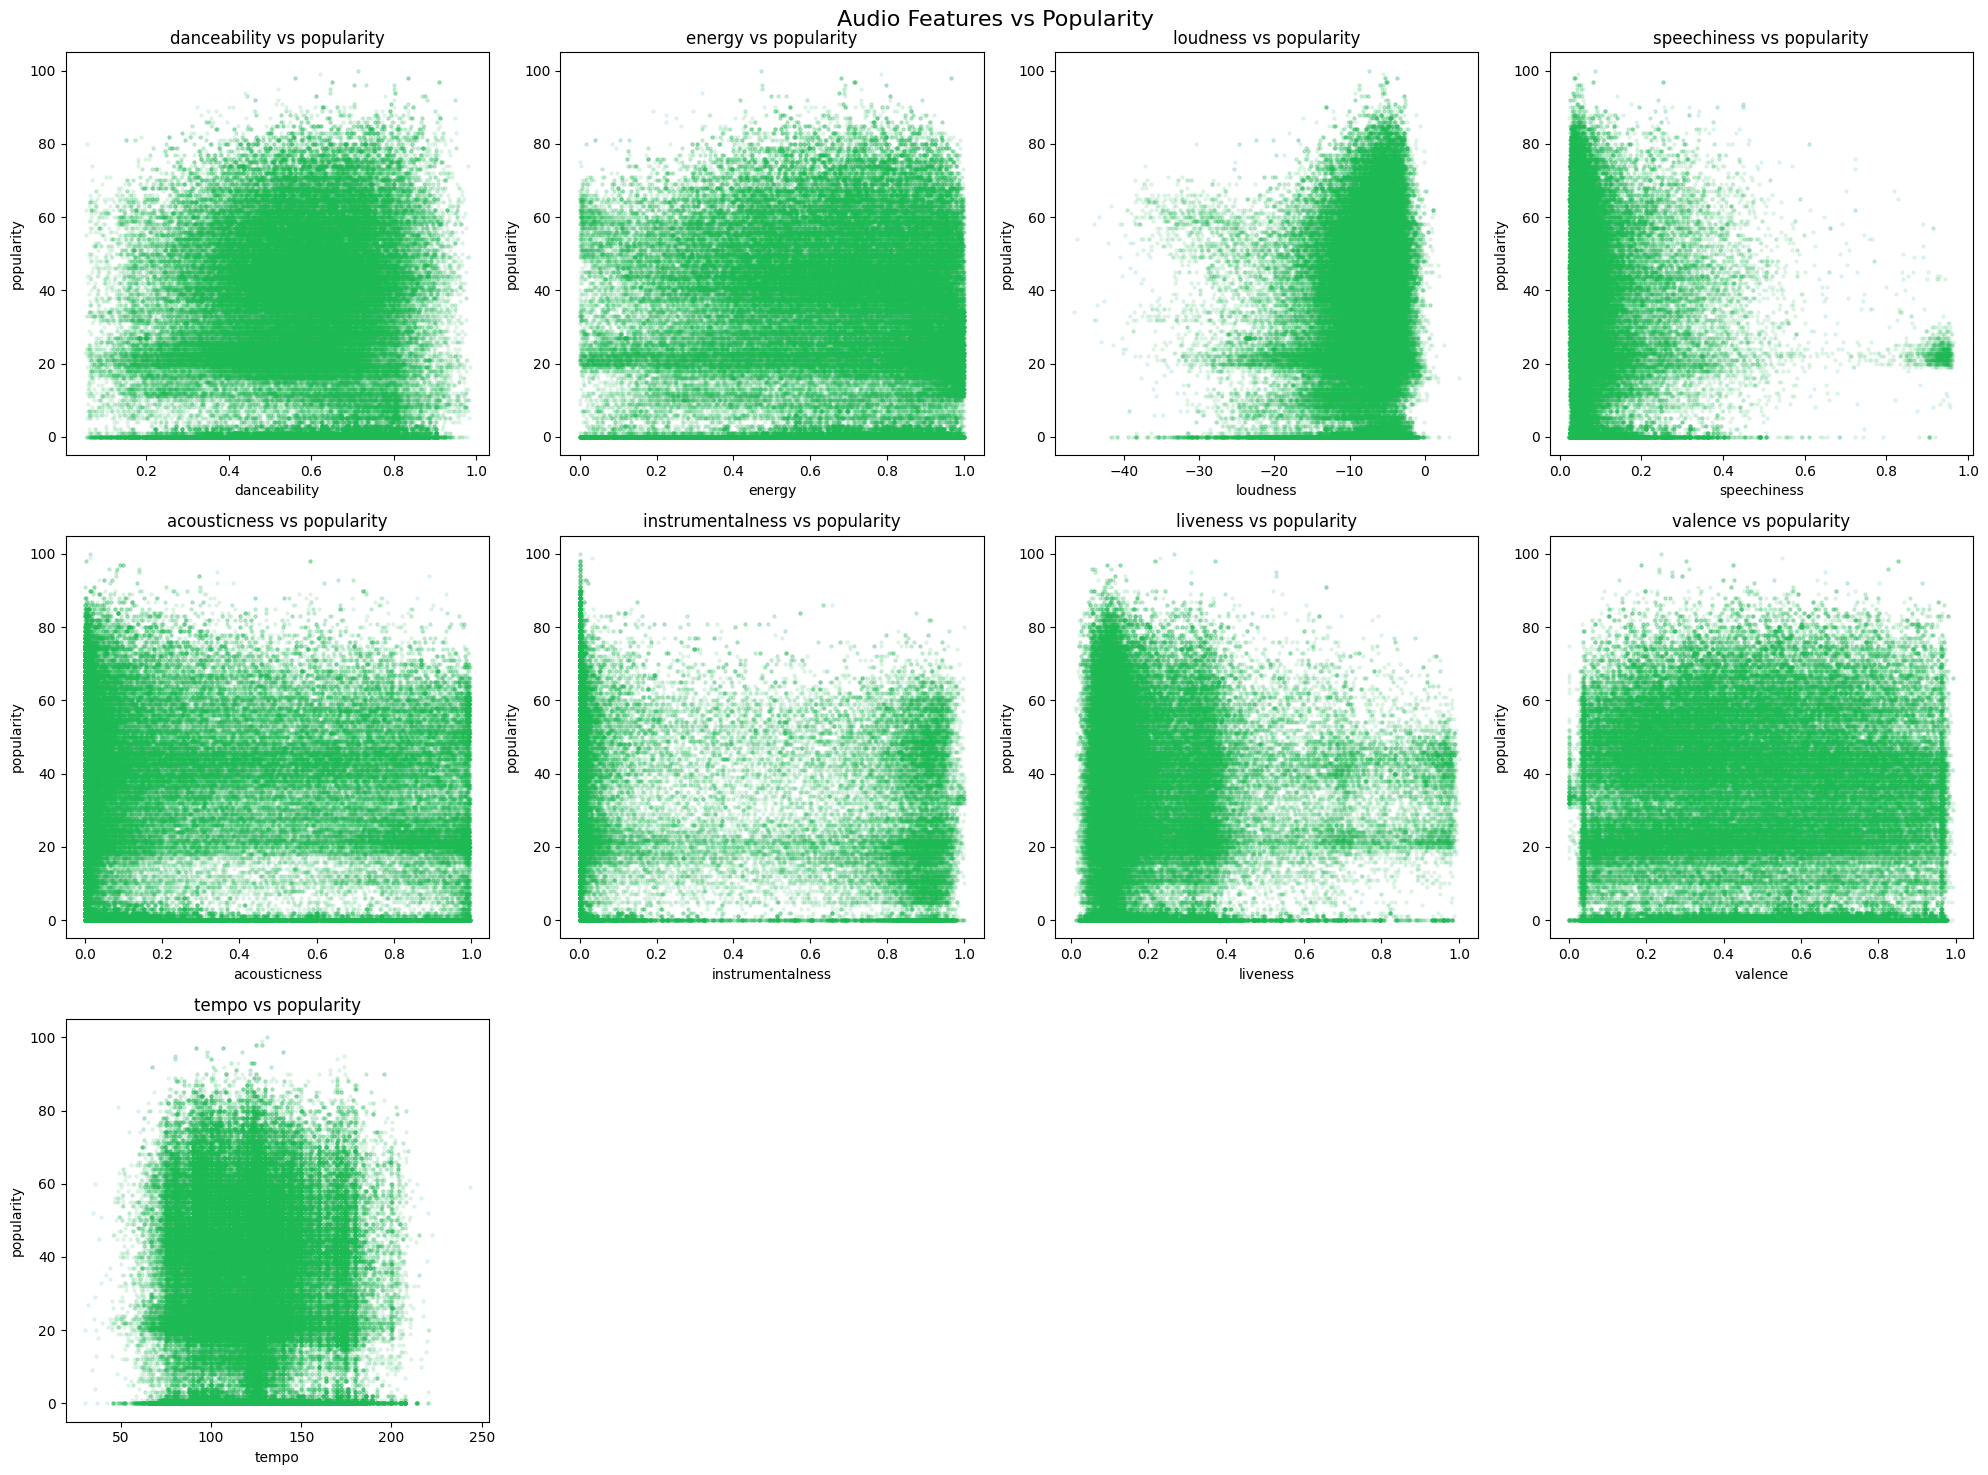

In [134]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for ax, feature in zip(axes.flatten(), numerical_features):
    ax.scatter(df[feature], df['popularity'], alpha=0.1, color='#1DB954', s=5)
    ax.set_xlabel(feature)
    ax.set_ylabel('popularity')
    ax.set_title(f'{feature} vs popularity')

# Hide the empty last subplot (11 features, 12 slots)
axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)
axes[2, 3].set_visible(False)
plt.suptitle('Audio Features vs Popularity', fontsize=16)
plt.tight_layout()
plt.savefig('feature_scatter.png', dpi=150)
plt.show()

## Feature Engineering

### Encode Categorical Features

In [137]:

df['explicit'] = df['explicit'].astype(int)
#key, mode, time_signature: treat as categorical
df = pd.get_dummies(df, columns=['key', 'mode', 'time_signature'], drop_first=True)

# one-hot encode
df = pd.get_dummies(df, columns=['track_genre'], drop_first=True)

print(f"Shape after encoding: {df.shape}")
df.head()

Shape after encoding: (113842, 146)


,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.461,...,False,False,False,False,False,False,False,False,False,False
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.166,...,False,False,False,False,False,False,False,False,False,False


### Drop unnecessary columns

In [163]:
cols_to_drop = ['index', 'track_id', 'artists', 'album_name', 'track_name']
df = df.drop(columns=cols_to_drop)

Shape after dropping: (113842, 141)
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'mode_1', 'time_signature_1', 'time_signature_3', 'time_signature_4', 'time_signature_5', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_blues', 'track_genre_brazil', 'track_genre_breakbeat', 'track_genre_british', 'track_genre_cantopop', 'track_genre_chicago-house', 'track_genre_children', 'track_genre_chill', 'track_genre_classical', 'track_genre_club', 'track_genre_comedy', 'track_genre_country', 'track_genre_dance', 'track_genre_dancehall', 'track_genre_death-metal', 'track_genre_deep-house', 'track_genre_detroit-techno', 'track_genre_disco', 'track_gen

In [167]:
print(f"Shape after dropping: {df.shape}")

Shape after dropping: (113842, 141)


### Handle multicollinearity

In [170]:
corr_matrix = df[['energy', 'loudness', 'acousticness']].corr()
print(corr_matrix)

# drop the weaker/more redundant ones
df = df.drop(columns=['loudness', 'acousticness'])
print(f"Shape after dropping correlated features: {df.shape}")

                energy  loudness  acousticness
energy        1.000000  0.762085     -0.735931
loudness      0.762085  1.000000     -0.591522
acousticness -0.735931 -0.591522      1.000000
Shape after dropping correlated features: (113842, 139)


**Multicollinearity:**
- energy <=> loudness (0.76) and energy <=> acousticness (-0.74) indicate 
  high redundancy between these three features
- Dropped loudness and acousticness, retaining energy as the most 
  interpretable production intensity feature
- Reduces risk of model instability caused by correlated predictors

### Log transform skewed features

In [175]:
skewed_features = ['speechiness', 'instrumentalness', 'liveness']

for feature in skewed_features:
    df[f'{feature}_log'] = np.log1p(df[feature])
    df = df.drop(columns=[feature])

print("Log transformed features added and originals dropped")
print(df.shape)

Log transformed features added and originals dropped
(113842, 139)


Log columns: ['speechiness_log', 'instrumentalness_log', 'liveness_log']


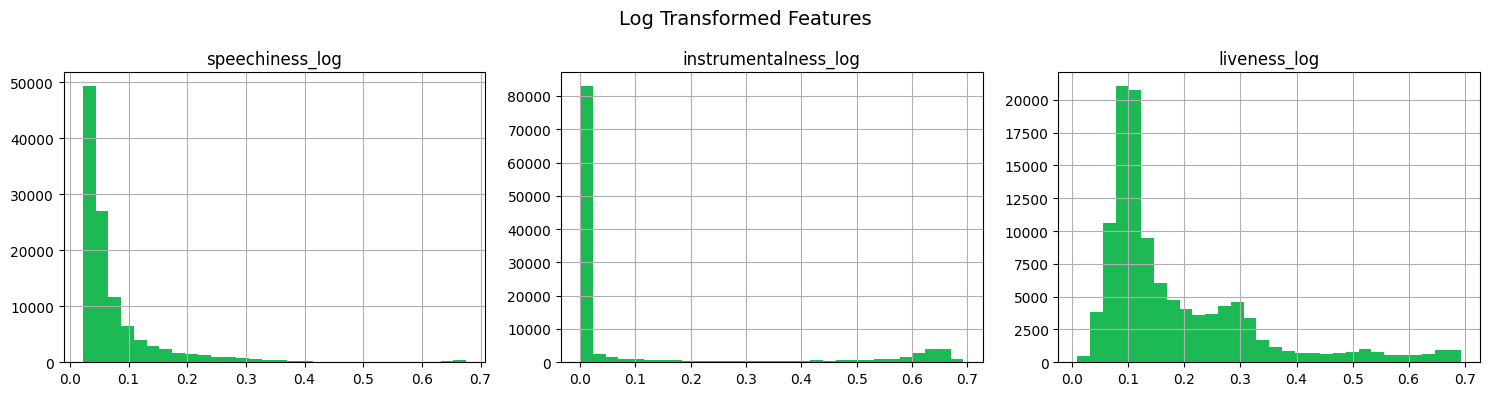

In [178]:
log_cols = [col for col in df.columns if '_log' in col]
print("Log columns:", log_cols)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, log_cols):
    df[col].hist(ax=ax, bins=30, color='#1DB954')
    ax.set_title(col)

plt.suptitle('Log Transformed Features', fontsize=14)
plt.tight_layout()
plt.show()

### Scaling numeric features

In [183]:
cols_to_scale = ['popularity', 'duration_ms', 'danceability', 'energy', 
                 'valence', 'tempo', 'speechiness_log', 
                 'instrumentalness_log', 'liveness_log']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df[cols_to_scale].describe().round(2)

,popularity,duration_ms,danceability,energy,valence,tempo,speechiness_log,instrumentalness_log,liveness_log
count,113842.00,113842.00,113842.00,113842.00,113842.00,113842.00,113842.00,113842.00,113842.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.49,-2.00,-3.00,-2.56,-1.83,-3.11,-0.68,-0.52,-1.26
25%,-0.73,-0.51,-0.65,-0.67,-0.83,-0.77,-0.51,-0.52,-0.65
50%,0.03,-0.14,0.07,0.17,-0.04,-0.01,-0.36,-0.52,-0.43
75%,0.75,0.31,0.74,0.84,0.80,0.60,0.04,-0.31,0.42
max,2.99,47.12,2.42,1.43,2.01,4.08,7.26,2.57,3.69


In [185]:
print(df['duration_ms'].describe())

extreme = (df['duration_ms'] > 3).sum()
print(f"Extreme duration outliers: {extreme}")

df['duration_ms'] = df['duration_ms'].clip(upper=3)
print(f"Max after capping: {df['duration_ms'].max()}")

count    1.138420e+05
mean    -1.997274e-17
std      1.000004e+00
min     -1.997151e+00
25%     -5.071235e-01
50%     -1.421245e-01
75%      3.148873e-01
max      4.712055e+01
Name: duration_ms, dtype: float64
Extreme duration outliers: 977
Max after capping: 3.0


## Modelling

### Split features and target(popularity)

In [212]:
X = df.drop(columns=['popularity'])
y = df['popularity']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (113842, 138)
Target shape: (113842,)


### Train/test split

In [210]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Training set: (91073, 138)
Testing set: (22769, 138)


### Linear Regression

In [215]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  RMSE: {lr_rmse:.4f}")
print(f"  MAE:  {lr_mae:.4f}")
print(f"  R²:   {lr_r2:.4f}")

Linear Regression:
  RMSE: 0.8649
  MAE:  0.6366
  R²:   0.2521


### Random Forest

In [218]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRandom Forest:")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  MAE:  {rf_mae:.4f}")
print(f"  R²:   {rf_r2:.4f}")


Random Forest:
  RMSE: 0.7030
  MAE:  0.4755
  R²:   0.5059


### XGBoost

In [197]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,  
    max_depth=8,        
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost:")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  MAE:  {xgb_mae:.4f}")
print(f"  R²:   {xgb_r2:.4f}")

XGBoost:
  RMSE: 0.8204
  MAE:  0.6107
  R²:   0.3271


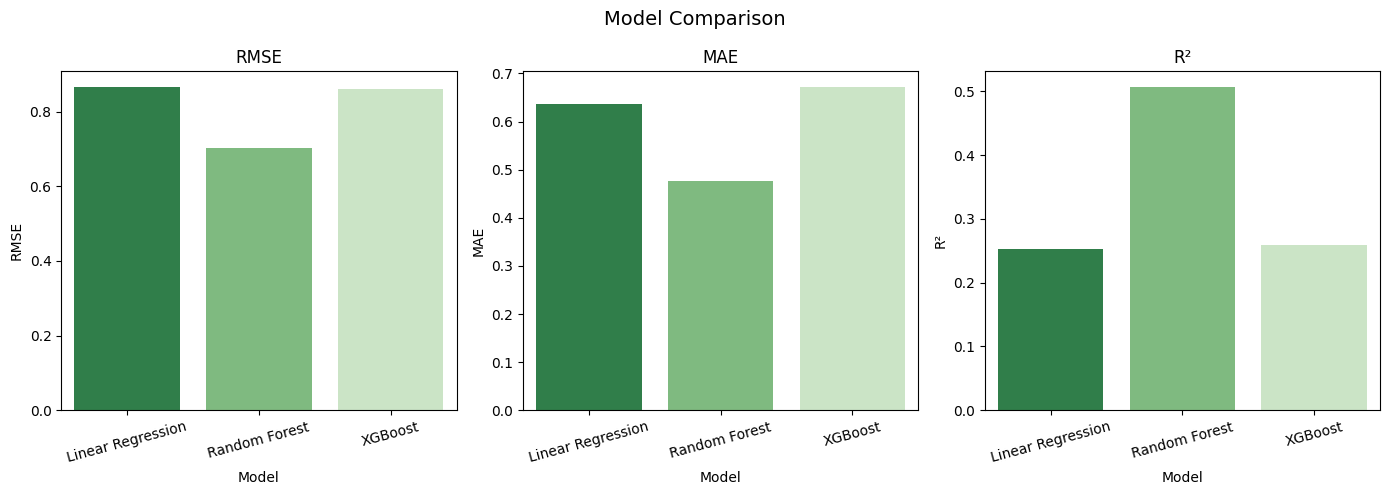

In [199]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    sns.barplot(ax=ax, x='Model', y=metric, hue='Model',
                data=results, legend=False, palette='Greens_r')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

**Findings:**
- Random Forest is the best performing model with R² = 0.51, 
  meaning it explains 51% of the variance in track popularity
- XGBoost surprisingly underperformed, scoring similarly to Linear 
  Regression (R² = 0.26) — this is likely because XGBoost needs 
  hyperparameter tuning to reach its potential, while Random Forest 
  performed well with default settings
- Linear Regression as expected is the weakest, confirming that 
  popularity has non-linear relationships that simple models can't capture

**Chosen model: Random Forest** with RMSE = 0.70, MAE = 0.48, R² = 0.51

### Feature importance from random forest

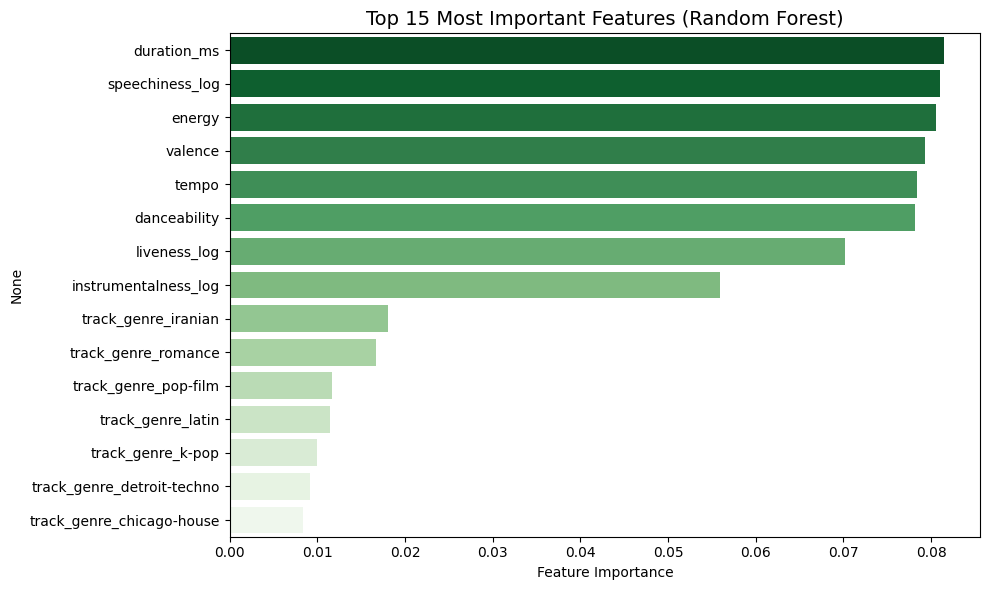

In [202]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index,
            hue=top_features.index, legend=False, palette='Greens_r')
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14)
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

**Feature Importance Findings:**

**Top audio features dominate:**
- duration_ms is the single most important feature => track length 
  has a surprisingly strong influence on popularity, possibly because 
  longer tracks accumulate more streams over time
- speechiness, energy, valence, tempo, and danceability all score 
  similarly high => confirming that the overall sonic character of a 
  track matters even if individual correlations were weak
- This makes sense => the model captures combined patterns across 
  features that simple pairwise correlation cannot detect

**Genre has limited but meaningful influence:**
- track_genre_iranian and track_genre_romance appear in the top 15, 
  consistent with our EDA finding that these were the lowest popularity 
  genres => the model uses genre membership as a signal to predict 
  lower popularity scores
- pop-film, latin, and k-pop also appear, matching our EDA top genres

**Key insight:**
- The contrast between weak pairwise correlations (EDA) and strong 
  feature importance (model) shows that audio features work together 
  as a combination rather than individually to predict popularity
- No single feature dominates => popularity is genuinely multi-dimensional

## Results & Conclusion

### Project Summary
This project analysed 113,843 Spotify tracks to understand what makes 
a song popular, using audio features, genre, and track metadata to 
build a popularity prediction model.

### Key Findings

**From EDA:**
- Popularity follows an approximately normal distribution (skewness 0.046) 
  centred around a mean of 33.2, with high popularity (80+) being rare
- pop-film and k-pop are the highest popularity genres on average (~60), 
  while iranian and romance score the lowest (~2–3)
- No single audio feature strongly correlates with popularity => the 
  highest individual correlation was loudness (0.05)
- Strong relationships exist between production features: energy ↔ loudness 
  (0.76) and energy ↔ acousticness (-0.74), confirming these capture 
  overlapping aspects of sound intensity
- The dataset is perfectly balanced with ~1,000 tracks per genre, 
  making it ideal for unbiased modelling

**From Modelling:**
- Random Forest outperformed both Linear Regression and XGBoost 
  with R² = 0.51, RMSE = 0.70, MAE = 0.48
- The model explains 51% of popularity variance => a reasonable result 
  given that external factors like artist fame, marketing, and playlist 
  placement are not captured in the dataset
- Feature importance revealed that duration_ms, speechiness, energy, 
  valence, tempo, and danceability are the strongest predictors
- Audio features work as a combination rather than individually => 
  explaining why pairwise correlations were weak but model performance 
  was moderate

### Limitations
- No artist metadata => artist fame is likely the strongest real-world 
  predictor of popularity but is absent from this dataset
- No temporal data => release date and trending patterns could 
  significantly improve predictions
- Popularity score is a snapshot in time => a track's score changes 
  as streaming activity changes

### Future Improvements
- Include artist follower count and historical popularity as features
- Try neural network models for capturing deeper non-linear patterns
- Build a classification version => predicting hit vs non-hit may be 
  more actionable for record labels
- Deploy as an interactive Streamlit dashboard where users can input 
  audio features and get a predicted popularity score

### Final Statement
This project demonstrates that while audio features alone cannot fully 
explain Spotify popularity, a Random Forest model combining track 
duration, sonic characteristics, and genre achieves meaningful 
predictive power. The findings suggest that popularity is a 
multi-dimensional outcome shaped by both measurable audio properties 
and unmeasurable human and commercial factors.